# APH/PPH Split

This notebook checks the APH/PPH split and hemorrhage logic:

1. APH and PPH incidence are in the ballpark of artifact expectations
2. Only severe hemorrhage cases die from hemorrhage
3. Misoprostol affects postpartum hemorrhage incidence but not antepartum hemorrhage incidence

In [1]:
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import math

import matplotlib.pyplot as plt
import matplotlib

import vivarium_gates_mncnh
from vivarium import Artifact, InteractiveContext
from vivarium.framework.configuration import build_model_specification

from vivarium_gates_mncnh.constants.data_keys import MATERNAL_HEMORRHAGE
from vivarium_gates_mncnh.constants.data_values import (
    ANEMIA_THRESHOLDS,
    COLUMNS,
    HEMORRHAGE_SEVERITY,
    SIMULATION_EVENT_NAMES,
    SIMULATION_STEPS,
)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [2]:
# Build a small interactive simulation for quick checks
model_spec_path = Path(vivarium_gates_mncnh.__file__).parent / 'model_specifications/model_spec.yaml'
base_spec = build_model_specification(model_spec_path)

DRAW = int(base_spec.configuration.input_data.input_draw_number)
DRAW_STR = "draw_"+str(DRAW)
POP_SIZE = 120_000

STEP_MAPPER = {name: i + 1 for i, name in enumerate(SIMULATION_STEPS)}

def make_spec(scenario: str = 'baseline', pop_size: int = POP_SIZE):
    spec = deepcopy(base_spec)
    spec.configuration.population.population_size = pop_size
    spec.configuration.intervention.scenario = scenario
    return spec

def make_sim(scenario: str = 'baseline', pop_size: int = POP_SIZE):
    return InteractiveContext(make_spec(scenario=scenario, pop_size=pop_size))

def run_to_step(sim: InteractiveContext, step_name: str):
    sim.take_steps(STEP_MAPPER[step_name])
    return sim

artifact = Artifact(base_spec.configuration.input_data.artifact_path)
draw_col = f'draw_{DRAW}'
print('Using artifact:', base_spec.configuration.input_data.artifact_path)
print('Using draw column:', draw_col)
print('Population size:', POP_SIZE)

Using artifact: /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/aph/ethiopia.hdf
Using draw column: draw_60
Population size: 120000


## 1) APH/PPH incidence and severity vs artifact

In [3]:
def get_art_by_age(art_key: str, sim_year: int, sim_location: str, sim_sex: str = 'Female') -> pd.DataFrame:
    art = artifact.load(art_key).reset_index()

    # Filter progressively; if a filter wipes everything out, keep previous data
    cur = art.copy()
    if 'location' in cur.columns:
        next_df = cur[cur['location'] == sim_location]
        if not next_df.empty:
            cur = next_df
    if 'sex' in cur.columns:
        next_df = cur[cur['sex'] == sim_sex]
        if not next_df.empty:
            cur = next_df
    if {'year_start', 'year_end'}.issubset(cur.columns):
        next_df = cur[(cur['year_start'] <= sim_year) & (sim_year < cur['year_end'])]
        if not next_df.empty:
            cur = next_df

    grouped = cur.groupby(['age_start', 'age_end'], as_index=False)[draw_col].mean()
    return grouped.sort_values(['age_start', 'age_end']).reset_index(drop=True)

def map_ages_to_art_values(ages: pd.Series, art_by_age: pd.DataFrame) -> pd.Series:
    intervals = pd.IntervalIndex.from_arrays(
        art_by_age['age_start'].astype(float),
        art_by_age['age_end'].astype(float),
        closed='left',
    )
    idx = intervals.get_indexer(ages.astype(float))
    out = pd.Series(np.nan, index=ages.index, dtype=float)
    matched = idx >= 0
    if matched.any():
        out.loc[matched] = art_by_age.iloc[idx[matched]][draw_col].to_numpy()
    return out

def weighted_incidence_from_artifact(
    pop: pd.DataFrame,
    art_key: str,
    eligible_mask: pd.Series,
    sim_year: int,
    sim_location: str,
    sim_sex: str = 'Female',
) -> float:
    art_by_age = get_art_by_age(art_key, sim_year=sim_year, sim_location=sim_location, sim_sex=sim_sex)
    eligible_ages = pop.loc[eligible_mask, COLUMNS.MOTHER_AGE]
    values = map_ages_to_art_values(eligible_ages, art_by_age)
    matched = values.notna()
    return float(values[matched].mean()) if matched.any() else np.nan

sim_year = int(base_spec.configuration.time.start.year)

# Single run for both APH and PPH checks (up to PPH step)
sim = make_sim('baseline')
run_to_step(sim, SIMULATION_EVENT_NAMES.POSTPARTUM_HEMORRHAGE)
pop = sim.get_population([
    COLUMNS.MOTHER_AGE,
    COLUMNS.LOCATION,
    COLUMNS.PREGNANCY_OUTCOME,
    COLUMNS.ANTEPARTUM_HEMORRHAGE,
    COLUMNS.POSTPARTUM_HEMORRHAGE,
])

sim_location = pop[COLUMNS.LOCATION].mode().iloc[0]

# Denominators must match component eligibility rules
aph_eligible = pop[COLUMNS.PREGNANCY_OUTCOME] != 'invalid'
pph_eligible = pop[COLUMNS.PREGNANCY_OUTCOME].isin(['live_birth', 'stillbirth'])

# Sim incidence
aph_cases = pop[COLUMNS.ANTEPARTUM_HEMORRHAGE].astype(bool)
pph_cases = pop[COLUMNS.POSTPARTUM_HEMORRHAGE].astype(bool)

aph_incidence_sim = float(aph_cases[aph_eligible].mean()) if int(aph_eligible.sum()) else np.nan
pph_incidence_sim = float(pph_cases[pph_eligible].mean()) if int(pph_eligible.sum()) else np.nan

# Artifact incidence weighted to simulated eligible age composition
aph_incidence_art = weighted_incidence_from_artifact(
    pop,
    MATERNAL_HEMORRHAGE.APH_INCIDENCE_RISK,
    aph_eligible,
    sim_year=sim_year,
    sim_location=sim_location,
)
pph_incidence_art = weighted_incidence_from_artifact(
    pop,
    MATERNAL_HEMORRHAGE.PPH_INCIDENCE_RISK,
    pph_eligible,
    sim_year=sim_year,
    sim_location=sim_location,
)

check1 = pd.DataFrame([
    {
        'cause': 'antepartum_hemorrhage',
        'sim_incidence': aph_incidence_sim,
        'artifact_incidence': aph_incidence_art,
        'incidence_ratio_sim_over_artifact': aph_incidence_sim / aph_incidence_art if aph_incidence_art else np.nan,
    },
    {
        'cause': 'postpartum_hemorrhage',
        'sim_incidence': pph_incidence_sim,
        'artifact_incidence': pph_incidence_art,
        'incidence_ratio_sim_over_artifact': pph_incidence_sim / pph_incidence_art if pph_incidence_art else np.nan,
    },
])

check1

2026-07-16 09:04:56.466 | INFO     | simulation_1-artifact_manager:80 - Running simulation from artifact located at /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/aph/ethiopia.hdf.


2026-07-16 09:04:56.467 | INFO     | simulation_1-artifact_manager:81 - Artifact base filter terms are ['draw == 60'].


2026-07-16 09:04:56.468 | INFO     | simulation_1-artifact_manager:82 - Artifact additional filter terms are None.


/ihme/homes/hjafari/miniconda3/envs/mncnh_mic7297_sim/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))


/ihme/homes/hjafari/miniconda3/envs/mncnh_mic7297_sim/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))
/ihme/homes/hjafari/miniconda3/envs/mncnh_mic7297_sim/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))


...

2026-07-16 09:08:49.460 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-14 00:00:00


2026-07-16 09:08:51.700 | WARNING  | simulation_1-population_manager:747 - The 'maternal_obstructed_labor_and_uterine_rupture.incidence_risk.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'maternal_obstructed_labor_and_uterine_rupture.incidence_risk.paf'.


2026-07-16 09:08:51.781 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-15 00:00:00


2026-07-16 09:08:54.361 | WARNING  | simulation_1-population_manager:747 - The 'postpartum_hemorrhage.incidence_risk.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'postpartum_hemorrhage.incidence_risk.paf'.


,cause,sim_incidence,artifact_incidence,incidence_ratio_sim_over_artifact
0,antepartum_hemorrhage,0.048733,0.047992,1.015449
1,postpartum_hemorrhage,0.098734,0.099235,0.994956


Text(0.5, 1.0, 'Antepartum and postpartum hemorrhage incidence')

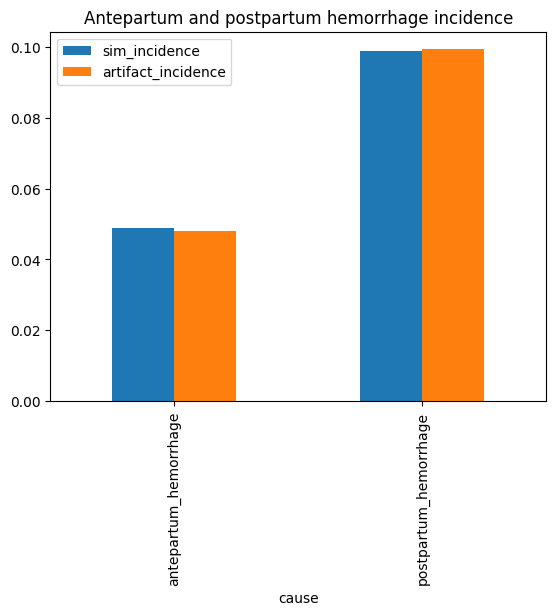

In [4]:
check1.plot(x="cause", y=["sim_incidence", "artifact_incidence"], kind="bar")
plt.title(f'Antepartum and postpartum hemorrhage incidence')
# TODO add error bars for sim

## 2) Only severe hemorrhage cases die from hemorrhage

In [5]:
sim_mort = make_sim('baseline')
run_to_step(sim_mort, SIMULATION_EVENT_NAMES.MORTALITY)

APH_SEVERITY_COL = f"{COLUMNS.ANTEPARTUM_HEMORRHAGE}_severity"
PPH_SEVERITY_COL = f"{COLUMNS.POSTPARTUM_HEMORRHAGE}_severity"

mort_pop = sim_mort.get_population([
    COLUMNS.MOTHER_CAUSE_OF_DEATH,
    APH_SEVERITY_COL,
    PPH_SEVERITY_COL,
])

hemo_cod = [COLUMNS.ANTEPARTUM_HEMORRHAGE, COLUMNS.POSTPARTUM_HEMORRHAGE]
dead_hemo = mort_pop[mort_pop[COLUMNS.MOTHER_CAUSE_OF_DEATH].isin(hemo_cod)]

bad_aph = dead_hemo[
    (dead_hemo[COLUMNS.MOTHER_CAUSE_OF_DEATH] == COLUMNS.ANTEPARTUM_HEMORRHAGE)
    & (dead_hemo[APH_SEVERITY_COL] != HEMORRHAGE_SEVERITY.SEVERE)
]
bad_pph = dead_hemo[
    (dead_hemo[COLUMNS.MOTHER_CAUSE_OF_DEATH] == COLUMNS.POSTPARTUM_HEMORRHAGE)
    & (dead_hemo[PPH_SEVERITY_COL] != HEMORRHAGE_SEVERITY.SEVERE)
]

assert len(bad_aph) == 0, f'{len(bad_aph)} non-severe APH deaths found'
assert len(bad_pph) == 0, f'{len(bad_pph)} non-severe PPH deaths found'
print(f'PASSED: all {len(dead_hemo)} hemorrhage deaths were severe')

2026-07-16 09:08:56.568 | INFO     | simulation_2-artifact_manager:80 - Running simulation from artifact located at /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/aph/ethiopia.hdf.


2026-07-16 09:08:56.570 | INFO     | simulation_2-artifact_manager:81 - Artifact base filter terms are ['draw == 60'].


2026-07-16 09:08:56.571 | INFO     | simulation_2-artifact_manager:82 - Artifact additional filter terms are None.


/ihme/homes/hjafari/miniconda3/envs/mncnh_mic7297_sim/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))


/ihme/homes/hjafari/miniconda3/envs/mncnh_mic7297_sim/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))
/ihme/homes/hjafari/miniconda3/envs/mncnh_mic7297_sim/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))


...

2026-07-16 09:13:15.921 | WARNING  | simulation_2-population_manager:747 - The 'maternal_sepsis_and_other_maternal_infections.incidence_risk.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'maternal_sepsis_and_other_maternal_infections.incidence_risk.paf'.


2026-07-16 09:13:16.171 | INFO     | simulation_2 - vivarium.framework.engine:280 - 2025-01-17 00:00:00


2026-07-16 09:13:18.723 | INFO     | simulation_2 - vivarium.framework.engine:280 - 2025-01-18 00:00:00


2026-07-16 09:13:21.513 | INFO     | simulation_2 - vivarium.framework.engine:280 - 2025-01-19 00:00:00


PASSED: all 60 hemorrhage deaths were severe


## 3) Misoprostol affects postpartum hemorrhage incidence but not antepartum hemorrhage incidence and aph and pph severe / total incidence match the severity fraction

In [6]:
APH_SEVERITY_COL = f"{COLUMNS.ANTEPARTUM_HEMORRHAGE}_severity"
PPH_SEVERITY_COL = f"{COLUMNS.POSTPARTUM_HEMORRHAGE}_severity"

def run_sim_for_pph_summary(scenario: str) -> pd.DataFrame:
    sim = make_sim(scenario)
    run_to_step(sim, SIMULATION_EVENT_NAMES.POSTPARTUM_HEMORRHAGE)



    pop = sim.get_population([
        COLUMNS.POSTPARTUM_HEMORRHAGE,
        COLUMNS.ANTEPARTUM_HEMORRHAGE,
        COLUMNS.MISOPROSTOL_AVAILABLE,
        COLUMNS.DELIVERY_FACILITY_TYPE,
        COLUMNS.PREGNANCY_OUTCOME,
        COLUMNS.MOTHER_AGE,
        APH_SEVERITY_COL,
        PPH_SEVERITY_COL,
    ])
    return pop

In [7]:
from vivarium_gates_mncnh.constants.data_values import PREGNANCY_OUTCOMES

def analyze_scenario_population(pop_table: pd.DataFrame, scenario: str, group: str):
    pop = pop_table.copy()

    # assert that for both aph and pph the set of people with moderate or severe incidence is exactly, 
    # and that theres only mod and sev for each
    assert ((pop[APH_SEVERITY_COL] == "moderate") | (pop[APH_SEVERITY_COL] == "severe")).equals(pop[COLUMNS.ANTEPARTUM_HEMORRHAGE])
    assert ((pop[PPH_SEVERITY_COL] == "moderate") | (pop[PPH_SEVERITY_COL] == "severe")).equals(pop[COLUMNS.POSTPARTUM_HEMORRHAGE])
    assert set(pop[pop[COLUMNS.ANTEPARTUM_HEMORRHAGE]][APH_SEVERITY_COL].tolist()) == {"moderate", "severe"}
    assert set(pop[pop[COLUMNS.POSTPARTUM_HEMORRHAGE]][PPH_SEVERITY_COL].tolist()) == {"moderate", "severe"}

    # main table row
    aph_count = pop[COLUMNS.ANTEPARTUM_HEMORRHAGE].sum()
    pph_count = pop[COLUMNS.POSTPARTUM_HEMORRHAGE].sum()
    n_preg = len(pop)
    n_ft_preg = (pop[COLUMNS.PREGNANCY_OUTCOME] != PREGNANCY_OUTCOMES.PARTIAL_TERM_OUTCOME).sum()
    aph_sev_count = (pop[APH_SEVERITY_COL] == "severe").sum()
    pph_sev_count = (pop[PPH_SEVERITY_COL] == "severe").sum()
    main_row = {
        'scenario': scenario, 
        'group': group, 
        'aph_incidence': aph_count / n_preg, 
        'pph_incidence': pph_count / n_ft_preg, 
        'aph_sev_frac': aph_sev_count / aph_count, 
        'pph_sev_frac': pph_sev_count / pph_count,
        'n_preg': n_preg,
        'n_ft_preg': n_ft_preg
    }

    def get_sev_frac_rows_by_strat(curpop, strat_col_name):
        sev_frac_strat_rows = []
        strat_vals = curpop[strat_col_name].unique()
        for strat_val in strat_vals:
            for timing in ['aph', 'pph']:
                timing_col_name = COLUMNS.ANTEPARTUM_HEMORRHAGE if timing == 'aph' else COLUMNS.POSTPARTUM_HEMORRHAGE
                sev_col_name = APH_SEVERITY_COL if timing == 'aph' else PPH_SEVERITY_COL
                pop_strat = curpop[(curpop[strat_col_name] == strat_val) & (curpop[timing_col_name])]
                sev_count = (pop_strat[sev_col_name] == "severe").sum()
                n = len(pop_strat)
                sev_frac_strat_rows.append({
                    'scenario': scenario,
                    'group': group,
                    'timing': timing,
                    'stratification_name': strat_col_name,
                    'stratification_val': strat_val,
                    'val': math.nan if n==0 else sev_count / n,
                    'n': n
                })
        return sev_frac_strat_rows
    
    # check severity fraction for aph and pph by age groups, delivery location and pregnancy outcome
    sev_frac_rows = []
    sev_frac_rows.extend(get_sev_frac_rows_by_strat(pop, COLUMNS.MOTHER_AGE))
    sev_frac_rows.extend(get_sev_frac_rows_by_strat(pop, COLUMNS.DELIVERY_FACILITY_TYPE))
    sev_frac_rows.extend(get_sev_frac_rows_by_strat(pop, COLUMNS.PREGNANCY_OUTCOME))

    return main_row, sev_frac_rows


def pph_summary_for_scenario(scenario: str) -> pd.DataFrame:
    pop = run_sim_for_pph_summary(scenario)
    pop[COLUMNS.MOTHER_AGE] = (pop[COLUMNS.MOTHER_AGE] // 5) * 5  # get age_start (ie group) from continuous age

    main_out = []
    sev_frac_out = []

    # overall group
    main_row, sev_frac_rows = analyze_scenario_population(pop, scenario, 'overall')
    main_out.append(main_row)
    sev_frac_out.extend(sev_frac_rows)

    # misoprostol=True and False group
    for value in [True, False]:
        sub = pop[pop[COLUMNS.MISOPROSTOL_AVAILABLE] == value]
        if len(sub) > 0:
            main_row, sev_frac_rows = analyze_scenario_population(sub, scenario, f'misoprostol_available={value}')
            main_out.append(main_row)
            sev_frac_out.extend(sev_frac_rows)

    # at-home group
    home = pop[pop[COLUMNS.DELIVERY_FACILITY_TYPE] == 'home']
    main_row, sev_frac_rows = analyze_scenario_population(home, scenario, 'home_only')
    main_out.append(main_row)
    sev_frac_out.extend(sev_frac_rows)

    return pd.DataFrame(main_out), pd.DataFrame(sev_frac_out)

baseline_main, baseline_sev_frac = pph_summary_for_scenario('baseline')
miso_vv_main, miso_vv_sev_frac = pph_summary_for_scenario('misoprostol_vv')

res_main = pd.concat([baseline_main, miso_vv_main], ignore_index=True).reset_index(drop=True)
res_sev_frac = pd.concat([baseline_sev_frac, miso_vv_sev_frac], ignore_index=True).reset_index(drop=True)

2026-07-16 09:13:32.045 | INFO     | simulation_3-artifact_manager:80 - Running simulation from artifact located at /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/aph/ethiopia.hdf.


2026-07-16 09:13:32.046 | INFO     | simulation_3-artifact_manager:81 - Artifact base filter terms are ['draw == 60'].


2026-07-16 09:13:32.047 | INFO     | simulation_3-artifact_manager:82 - Artifact additional filter terms are None.


/ihme/homes/hjafari/miniconda3/envs/mncnh_mic7297_sim/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))


/ihme/homes/hjafari/miniconda3/envs/mncnh_mic7297_sim/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))
/ihme/homes/hjafari/miniconda3/envs/mncnh_mic7297_sim/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))
/ihme/homes/hjafari/miniconda3/envs/mncnh_mic7297_sim/lib/python3.11/site-packages/vivarium/framework/lookup/interpolati

...

2026-07-16 09:19:56.172 | INFO     | simulation_4 - vivarium.framework.engine:280 - 2025-01-13 00:00:00


2026-07-16 09:19:57.777 | INFO     | simulation_4 - vivarium.framework.engine:280 - 2025-01-14 00:00:00


2026-07-16 09:19:59.038 | WARNING  | simulation_4-population_manager:747 - The 'maternal_obstructed_labor_and_uterine_rupture.incidence_risk.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'maternal_obstructed_labor_and_uterine_rupture.incidence_risk.paf'.


2026-07-16 09:19:59.070 | INFO     | simulation_4 - vivarium.framework.engine:280 - 2025-01-15 00:00:00


2026-07-16 09:20:00.520 | WARNING  | simulation_4-population_manager:747 - The 'postpartum_hemorrhage.incidence_risk.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'postpartum_hemorrhage.incidence_risk.paf'.


In [8]:
res_main = res_main.reset_index(drop=True).set_index(["scenario", "group"])
res_main

aph_incidence  pph_incidence  aph_sev_frac  pph_sev_frac  n_preg  n_ft_preg
scenario       group                                                                                                   
baseline       overall                           0.048733       0.098734      0.158516      0.162669  120000      67555
               misoprostol_available=False       0.048733       0.098734      0.158516      0.162669  120000      67555
               home_only                         0.048477       0.101856      0.154114      0.171258   29581      29581
misoprostol_vv overall                           0.048733       0.094427      0.158516      0.161624  120000      67555
               misoprostol_available=True        0.048373       0.061019      0.142132      0.164990    8145       8145
               misoprostol_available=False       0.048760       0.099007      0.159699      0.161340  111855      59410
               home_only                         0.048477       0.092019      0.154114      0.169728   29581      29581

In [9]:
miso_avail_row = res_main.loc[("misoprostol_vv", "misoprostol_available=True")]
miso_unavail_row = res_main.loc[("misoprostol_vv", "misoprostol_available=False")]
assert abs(1 - miso_avail_row["aph_incidence"] / miso_unavail_row["aph_incidence"]) < .01 # less than 1% difference
assert miso_unavail_row["pph_incidence"] / miso_avail_row["pph_incidence"] > artifact.load("intervention.no_misoprostol_risk.relative_risk")[DRAW_STR].mean() * .95  # at least 95% of RR
# RR checked more thoroughly at bottom of maternal.ipynb

In [10]:
# This was to check pph severity fractions by stratifications but the issue turned out to be with the v&v
#res_sev_frac[(res_sev_frac.scenario == "baseline") & (res_sev_frac.group == "overall") & (res_sev_frac.timing == "pph")]

In [11]:
res_main_sev = res_main[["aph_sev_frac", "pph_sev_frac"]]
art_sev_frac = artifact.load("cause.maternal_hemorrhage.severe_fraction")[DRAW_STR]
art_sev_frac = art_sev_frac[art_sev_frac != 0].mean() # barely varies by age
targets = pd.DataFrame()
targets.index = res_main.index
targets["aph_sev_frac"] = art_sev_frac
targets["pph_sev_frac"] = art_sev_frac
res_main_sev / targets

aph_sev_frac  pph_sev_frac
scenario       group                                                  
baseline       overall                          0.995549      1.021632
               misoprostol_available=False      0.995549      1.021632
               home_only                        0.967907      1.075576
misoprostol_vv overall                          0.995549      1.015071
               misoprostol_available=True       0.892652      1.036210
               misoprostol_available=False      1.002983      1.013285
               home_only                        0.967907      1.065968

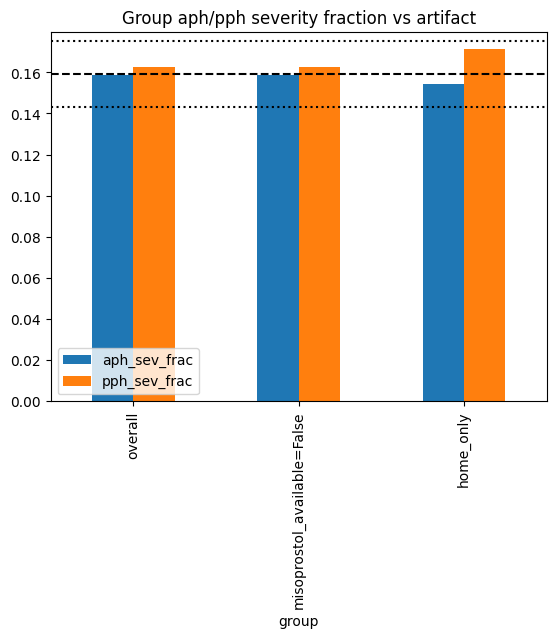

In [12]:
res_main_sev.reset_index()[res_main_sev.reset_index().scenario == "baseline"].plot(kind="bar", x="group", y=["aph_sev_frac", "pph_sev_frac"])
plt.axhline(art_sev_frac, color='k', linestyle='--')
plt.axhline(art_sev_frac * 1.1, color='k', linestyle='dotted')
plt.axhline(art_sev_frac * 0.9, color='k', linestyle='dotted')
plt.title("Group aph/pph severity fraction vs artifact")
plt.show()
# TODO add the below standard errors (and delete table)

In [13]:
# number of standard errors away from targets
n = pd.concat([res_main["n_preg"] * res_main["aph_incidence"], res_main["n_ft_preg"]* res_main["pph_incidence"]], axis=1).rename(columns={0: "aph_sev_frac", 1: "pph_sev_frac"})
std_error = np.sqrt(res_main_sev * (1 - res_main_sev) / n)
num_std_errors = (res_main_sev - targets) / std_error
assert((num_std_errors.abs() < 1.96).all().all())  # all aph and pph severity fractions within 1.96 std errors of target
num_std_errors

aph_sev_frac  pph_sev_frac
scenario       group                                                  
baseline       overall                         -0.148383      0.762184
               misoprostol_available=False     -0.148383      0.762184
               home_only                       -0.535945      1.753300
misoprostol_vv overall                         -0.148383      0.520665
               misoprostol_available=True      -0.971618      0.346293
               misoprostol_available=False      0.095741      0.441030
               home_only                       -0.535945      1.459827

In [14]:
# Directional check: compare home-birth PPH incidence across scenarios.
# Misoprostol is only available to home births so that is the right comparison group.
baseline_home = float(res_main.reset_index().query("scenario == 'baseline' and group == 'home_only'")['pph_incidence'].iloc[0])
miso_home = float(res_main.reset_index().query("scenario == 'misoprostol_vv' and group == 'home_only'")['pph_incidence'].iloc[0])

pd.DataFrame([
    {'metric': 'baseline_home_birth_pph_incidence', 'value': baseline_home},
    {'metric': 'misoprostol_vv_home_birth_pph_incidence', 'value': miso_home},
    {'metric': 'directional_pass', 'value': miso_home < baseline_home},
])
assert(miso_home < baseline_home)